# CreditWise: Loan Approval Prediction using Machine Learning

## Project Overview

Financial institutions receive thousands of loan applications every day. Assessing whether an applicant is likely to repay a loan is one of the most critical tasks in the lending process. Traditionally, this decision relied heavily on manual evaluation and predefined rules. Machine Learning provides a scalable and data-driven alternative by identifying patterns within historical loan application data.

In this project, a classification model is developed to predict whether a loan application should be approved based on applicant information such as income, credit score, employment status, education level, loan amount, and other financial attributes.

The project follows a complete machine learning workflow including:

- Data loading
- Data preprocessing
- Missing value handling
- Exploratory Data Analysis (EDA)
- Feature Encoding
- Feature Scaling
- Model Building
- Model Evaluation
- Performance Comparison

Three classification algorithms are implemented and compared:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Gaussian Naive Bayes

The objective is to identify the model that provides the best predictive performance while demonstrating a clean, reproducible machine learning pipeline suitable for real-world applications.

---

## Dataset

The dataset contains demographic, financial and employment-related information of loan applicants.

Target Variable:

**Loan_Status**

- Approved
- Rejected

The remaining features represent applicant characteristics that influence loan approval decisions.

---

## Project Objectives

- Understand the dataset structure
- Handle missing values effectively
- Explore relationships between variables
- Prepare data for machine learning
- Train multiple classification models
- Compare model performance
- Identify the most suitable model for loan approval prediction

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan_approval_data.csv")
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [3]:
print("Shape of Dataset:", df.shape)
print(df.columns)
df.info()

Shape of Dataset: (1000, 20)
Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income',
       'Employment_Status', 'Age', 'Marital_Status', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Loan_Purpose',
       'Property_Area', 'Education_Level', 'Gender', 'Employer_Category',
       'Loan_Approved'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-nu

In [4]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [5]:
df.describe(include = "object")

,Employment_Status,Marital_Status,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
count,950,950,950,950,950,950,950,950
unique,4,2,5,3,2,2,5,2
top,Salaried,Married,Business,Urban,Graduate,Male,Private,No
freq,465,593,202,467,672,571,372,652


# Handle Missing Values


In [6]:
missing = df.isnull().sum()
print(missing)

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64


In [7]:
missing_percent = (df.isnull().sum() / len(df)) * 100

print(missing_percent.sort_values(ascending=False))

Applicant_ID          5.0
Applicant_Income      5.0
Employer_Category     5.0
Gender                5.0
Education_Level       5.0
Property_Area         5.0
Loan_Purpose          5.0
Loan_Term             5.0
Loan_Amount           5.0
Collateral_Value      5.0
Savings               5.0
DTI_Ratio             5.0
Existing_Loans        5.0
Credit_Score          5.0
Dependents            5.0
Marital_Status        5.0
Age                   5.0
Employment_Status     5.0
Coapplicant_Income    5.0
Loan_Approved         5.0
dtype: float64


In [8]:
categorical_cols = df.select_dtypes(include = ["object"]).columns
numerical_cols = df.select_dtypes(include = ["number"]).columns

In [9]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [10]:
cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

### Only a small percentage of missing values were observed, primarily in Credit Score and Loan Amount. Since the missing proportion was low, mean imputation for numerical variables and mode imputation for categorical variables was considered appropriate.

In [11]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


# EDA

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64


Text(0.5, 1.0, 'Is Loan approved ?')

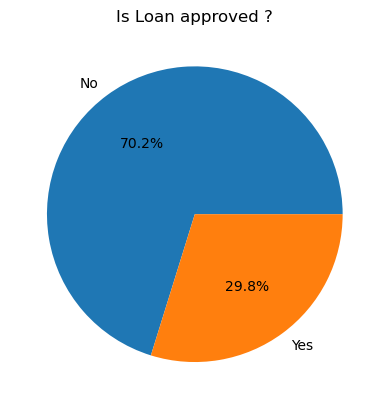

In [12]:
# how balanced the classes are
classes_count = df["Loan_Approved"].value_counts()
print(classes_count)
plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Is Loan approved ?")

Gender
Male      621
Female    379
Name: count, dtype: int64
Property_Area
Urban        517
Rural        294
Semiurban    189
Name: count, dtype: int64


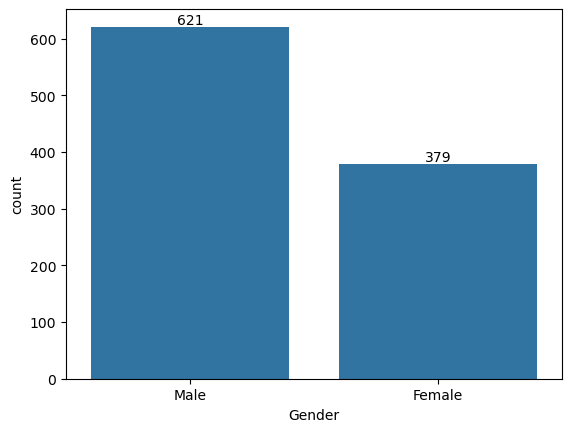

In [13]:
gender_count = df["Gender"].value_counts()
print(gender_count)
ax = sns.barplot(gender_count)
ax.bar_label(ax.containers[0])

edu_count = df['Property_Area'].value_counts()
print(edu_count)

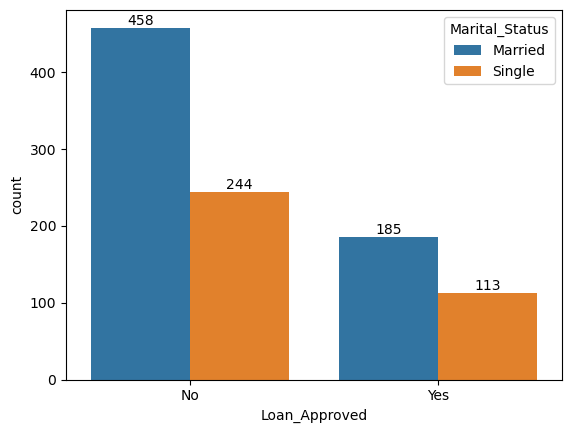

In [14]:
# Clean long-form approach using seaborn's native aggregation
ax = sns.countplot(data=df, x="Loan_Approved", hue="Marital_Status")

# Add value labels to every bar container
for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [15]:
df = df.drop("Applicant_ID",axis = 1)

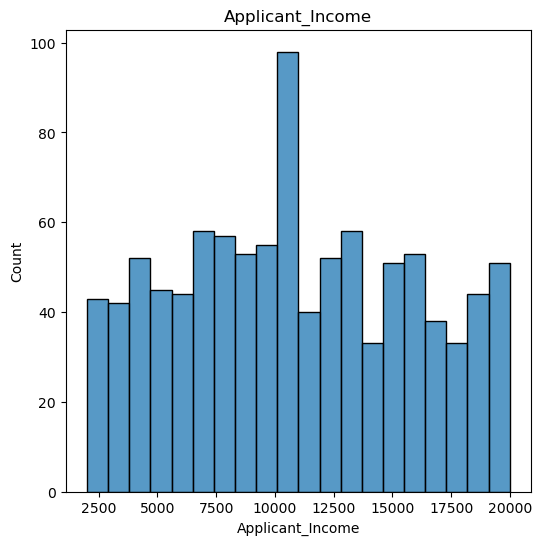

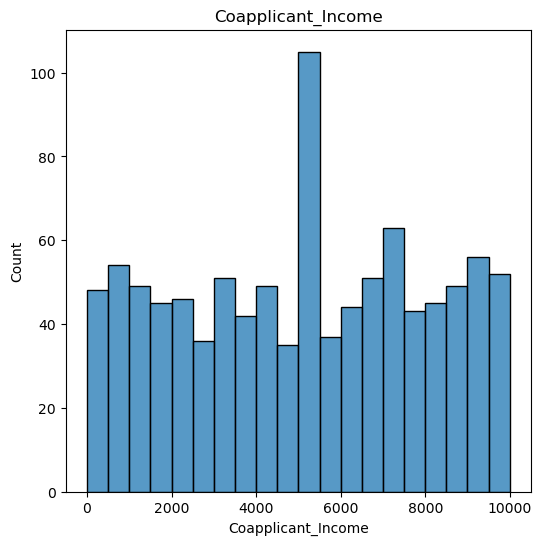

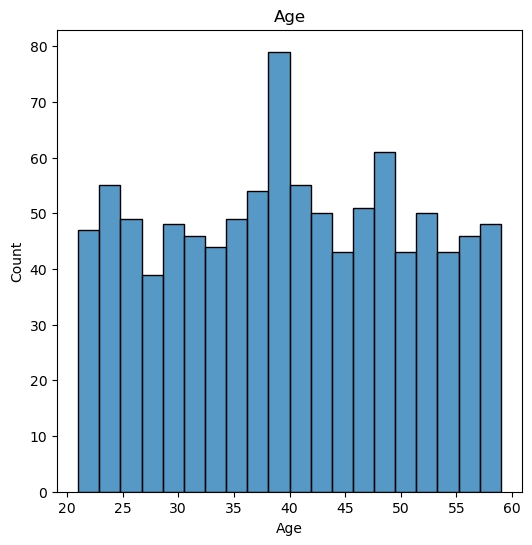

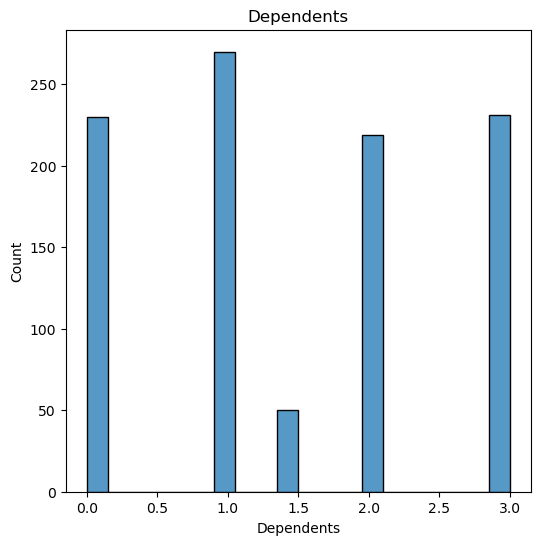

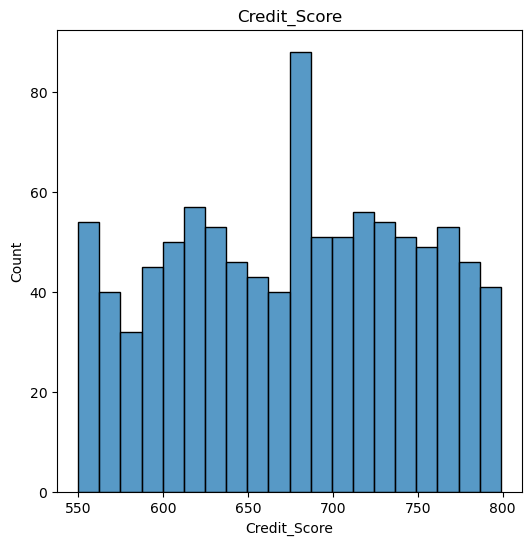

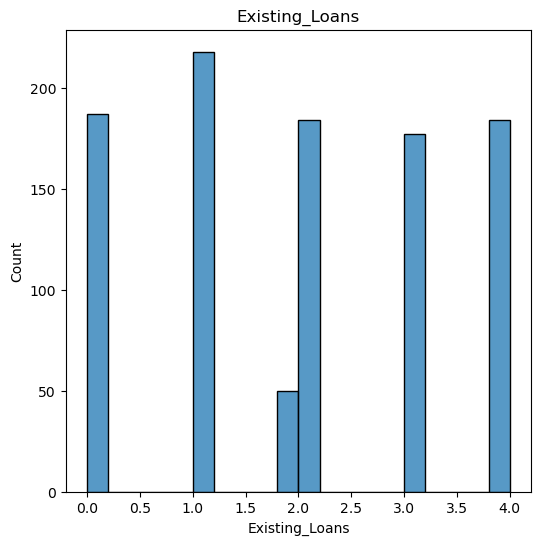

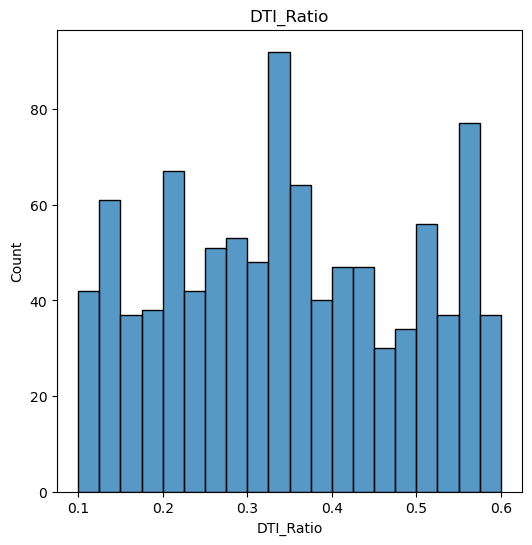

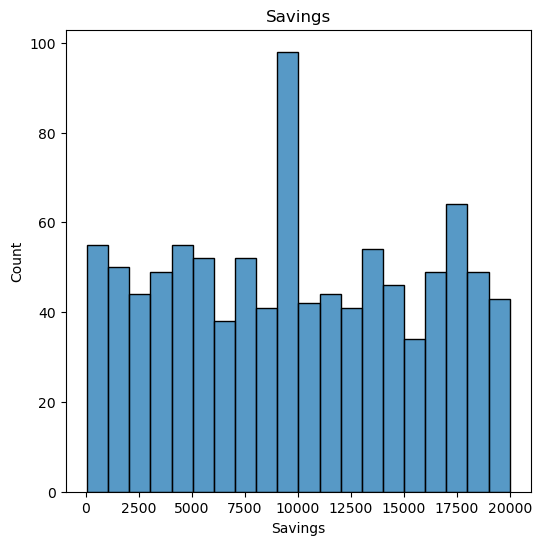

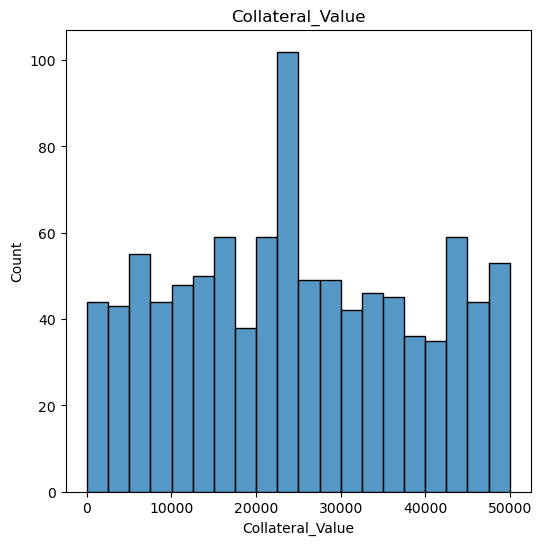

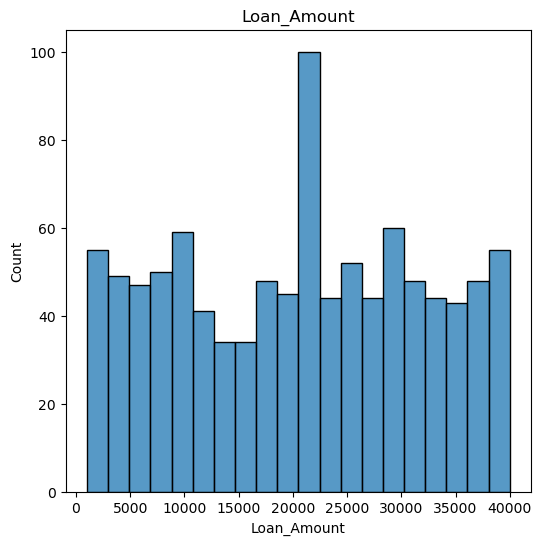

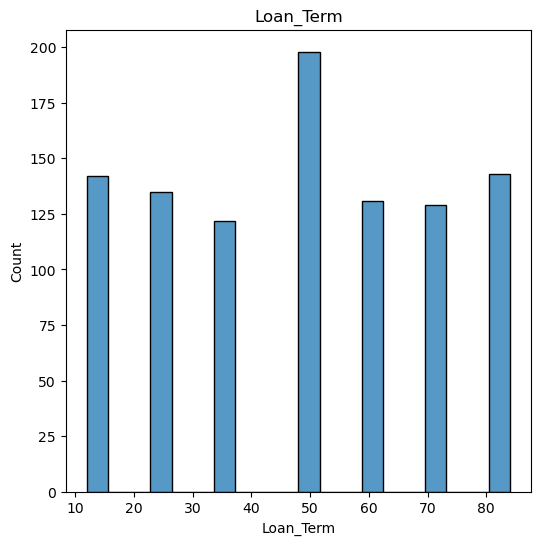

In [16]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

for column in numerical_columns:

    plt.figure(figsize=(6,6))

    sns.histplot(df[column], bins = 20)

    plt.title(column)

    plt.show()

<Axes: xlabel='Applicant_Income', ylabel='Count'>

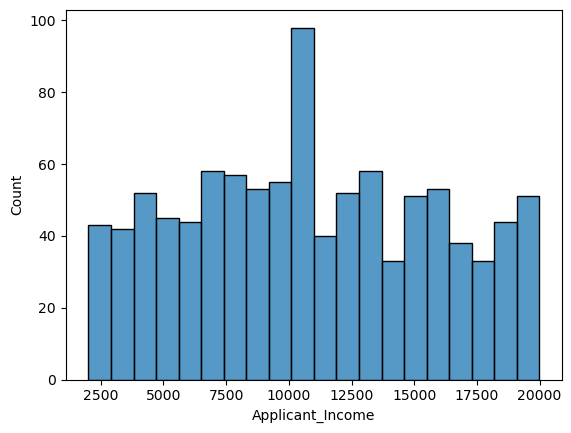

In [17]:
sns.histplot(data = df,
             x = "Applicant_Income",
             bins = 20
              )

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

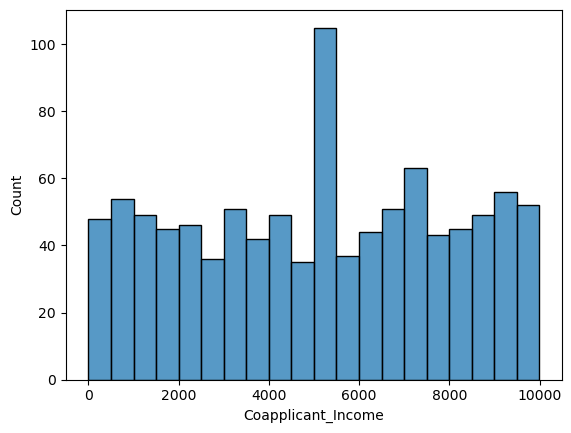

In [18]:
sns.histplot(data = df,
             x = "Coapplicant_Income",
             bins = 20
              )

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

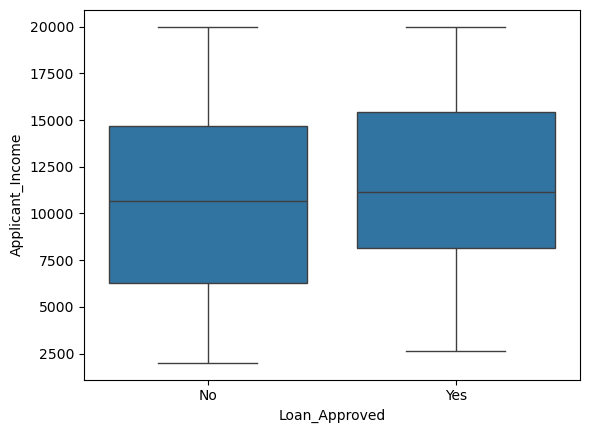

In [19]:
sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income",
    
)

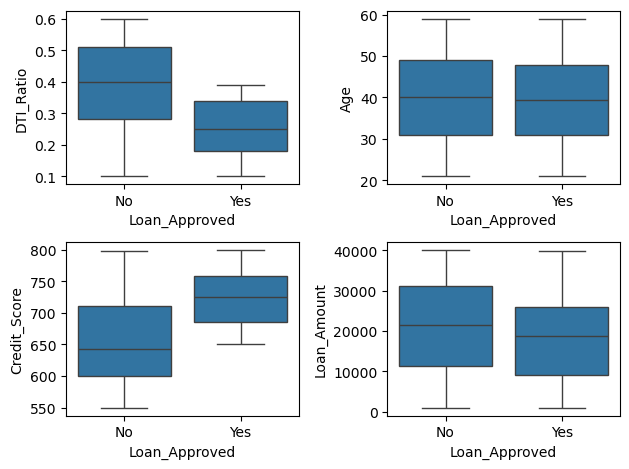

In [20]:
fig , axes = plt.subplots(2,2)

sns.boxplot(ax = axes[0,0], data = df, x = "Loan_Approved", y = "DTI_Ratio")
sns.boxplot(ax = axes[0,1], data = df, x = "Loan_Approved", y = "Age")
sns.boxplot(ax = axes[1,0], data = df, x = "Loan_Approved", y = "Credit_Score")
sns.boxplot(ax = axes[1,1], data = df, x = "Loan_Approved", y = "Loan_Amount")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

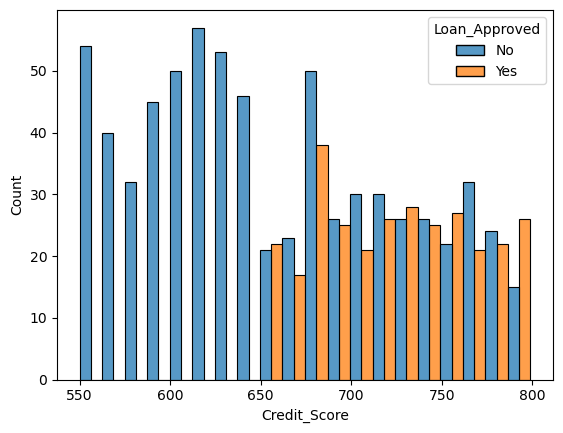

In [21]:
sns.histplot(data = df,
            x = "Credit_Score",
            hue = "Loan_Approved",
            multiple= "dodge",
            bins = 20)

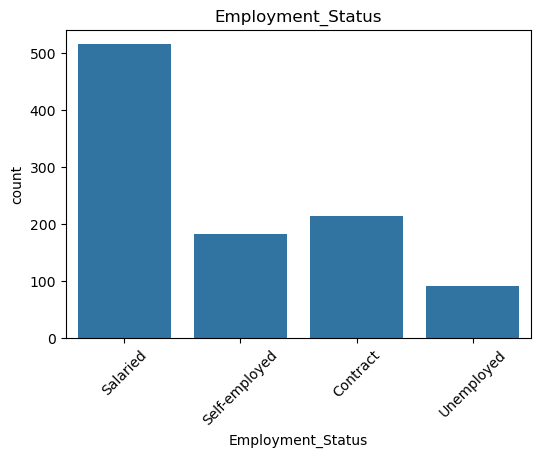

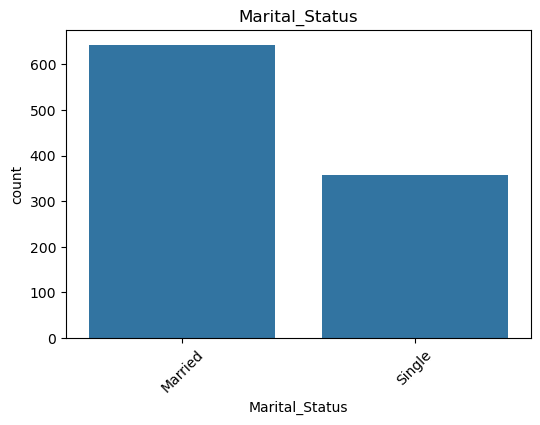

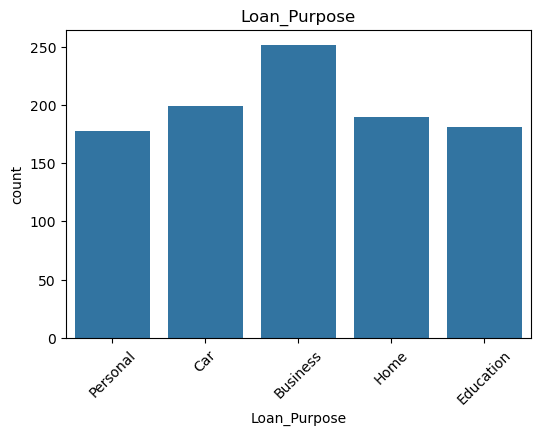

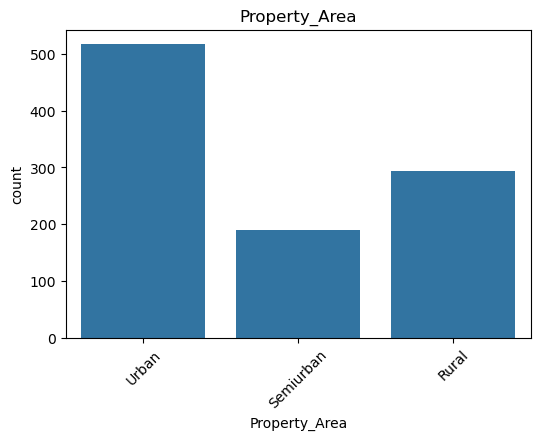

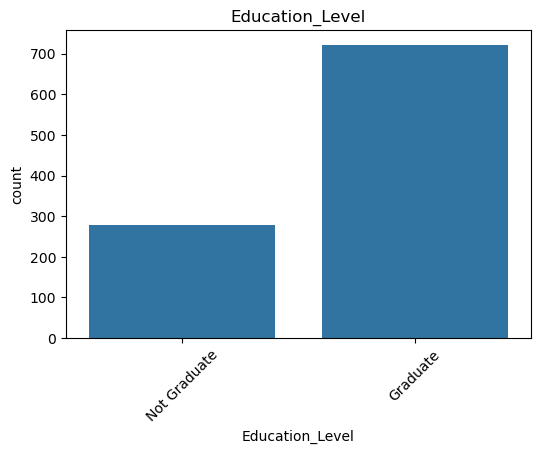

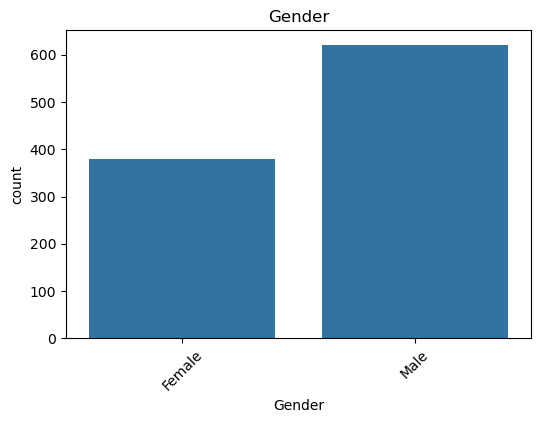

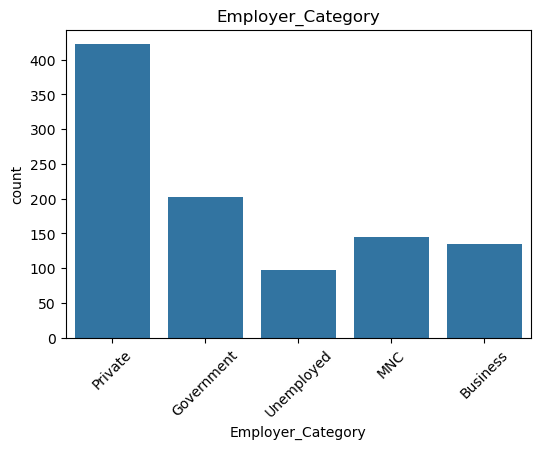

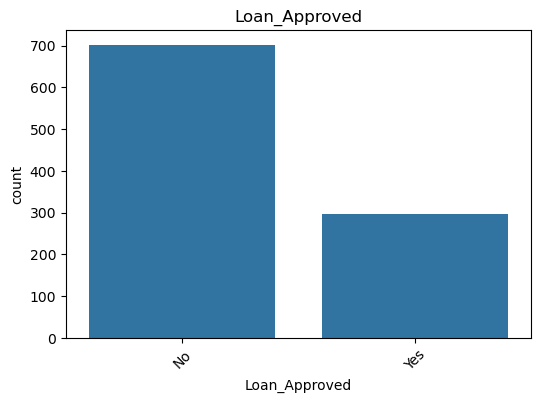

In [22]:
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:

    plt.figure(figsize=(6,4))

    sns.countplot(data=df, x=column)

    plt.xticks(rotation=45)

    plt.title(column)

    plt.show()

In [23]:
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


# Encoding


In [24]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [25]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder 

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

ohe = OneHotEncoder(drop = "first" , sparse_output = False , handle_unknown = "ignore")
one_hot_cols = ["Employment_Status", "Marital_Status","Property_Area", "Loan_Purpose",
       "Gender","Employer_Category"]

encoded = ohe.fit_transform(df[one_hot_cols])

In [26]:

encoded_df = pd.DataFrame(encoded , columns = ohe.get_feature_names_out(one_hot_cols), index=df.index)

df = pd.concat([df.drop(columns = one_hot_cols), encoded_df], axis = 1)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Correlation Heatmap

In [28]:
num_cols = df.select_dtypes(include = "number")
corr_matrix = num_cols.corr()
corr_matrix

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Urban,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
Applicant_Income,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,...,-0.036260,-0.083398,0.032794,0.074209,-0.031234,-0.020871,-0.025011,0.102589,-0.044639,-0.011995
Coapplicant_Income,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,...,0.030045,-0.020148,0.028000,0.016022,0.059549,-0.010148,-0.001146,0.037640,0.004312,-0.047929
Age,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,...,-0.025661,-0.025521,-0.006283,0.029865,0.037293,0.048402,-0.066041,0.021232,-0.012960,0.072462
Dependents,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,...,0.024082,-0.043685,-0.044642,0.027343,-0.005785,0.013706,-0.009250,-0.018757,0.030197,-0.054147
Credit_Score,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,...,0.004445,-0.030142,0.026013,-0.008658,0.015324,-0.039739,-0.007076,0.066736,-0.000049,-0.046087
Existing_Loans,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,...,0.035629,-0.025228,-0.010035,0.001777,0.023212,-0.038762,-0.009642,0.030520,-0.019306,0.045391
DTI_Ratio,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,...,-0.006156,-0.020907,0.040432,-0.014125,-0.036648,0.009624,-0.007214,0.002090,-0.003506,0.026018
Savings,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,...,0.016833,-0.009133,0.032558,-0.012217,-0.028948,-0.006667,-0.011683,0.004381,-0.030208,0.027178
Collateral_Value,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,0.002660,...,0.007975,0.031112,0.040406,-0.050975,-0.007120,0.000897,0.035760,-0.013464,-0.014480,-0.009655
Loan_Amount,-0.024143,0.001596,0.013502,-0.017409,0.001002,-0.021035,0.075784,-0.012208,0.002660,1.000000,...,-0.050076,-0.006788,-0.006119,-0.000930,0.032498,0.103456,0.013108,-0.025975,0.013923,-0.026566


In [29]:
num_cols.corr()["Loan_Approved"].sort_values(ascending = False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

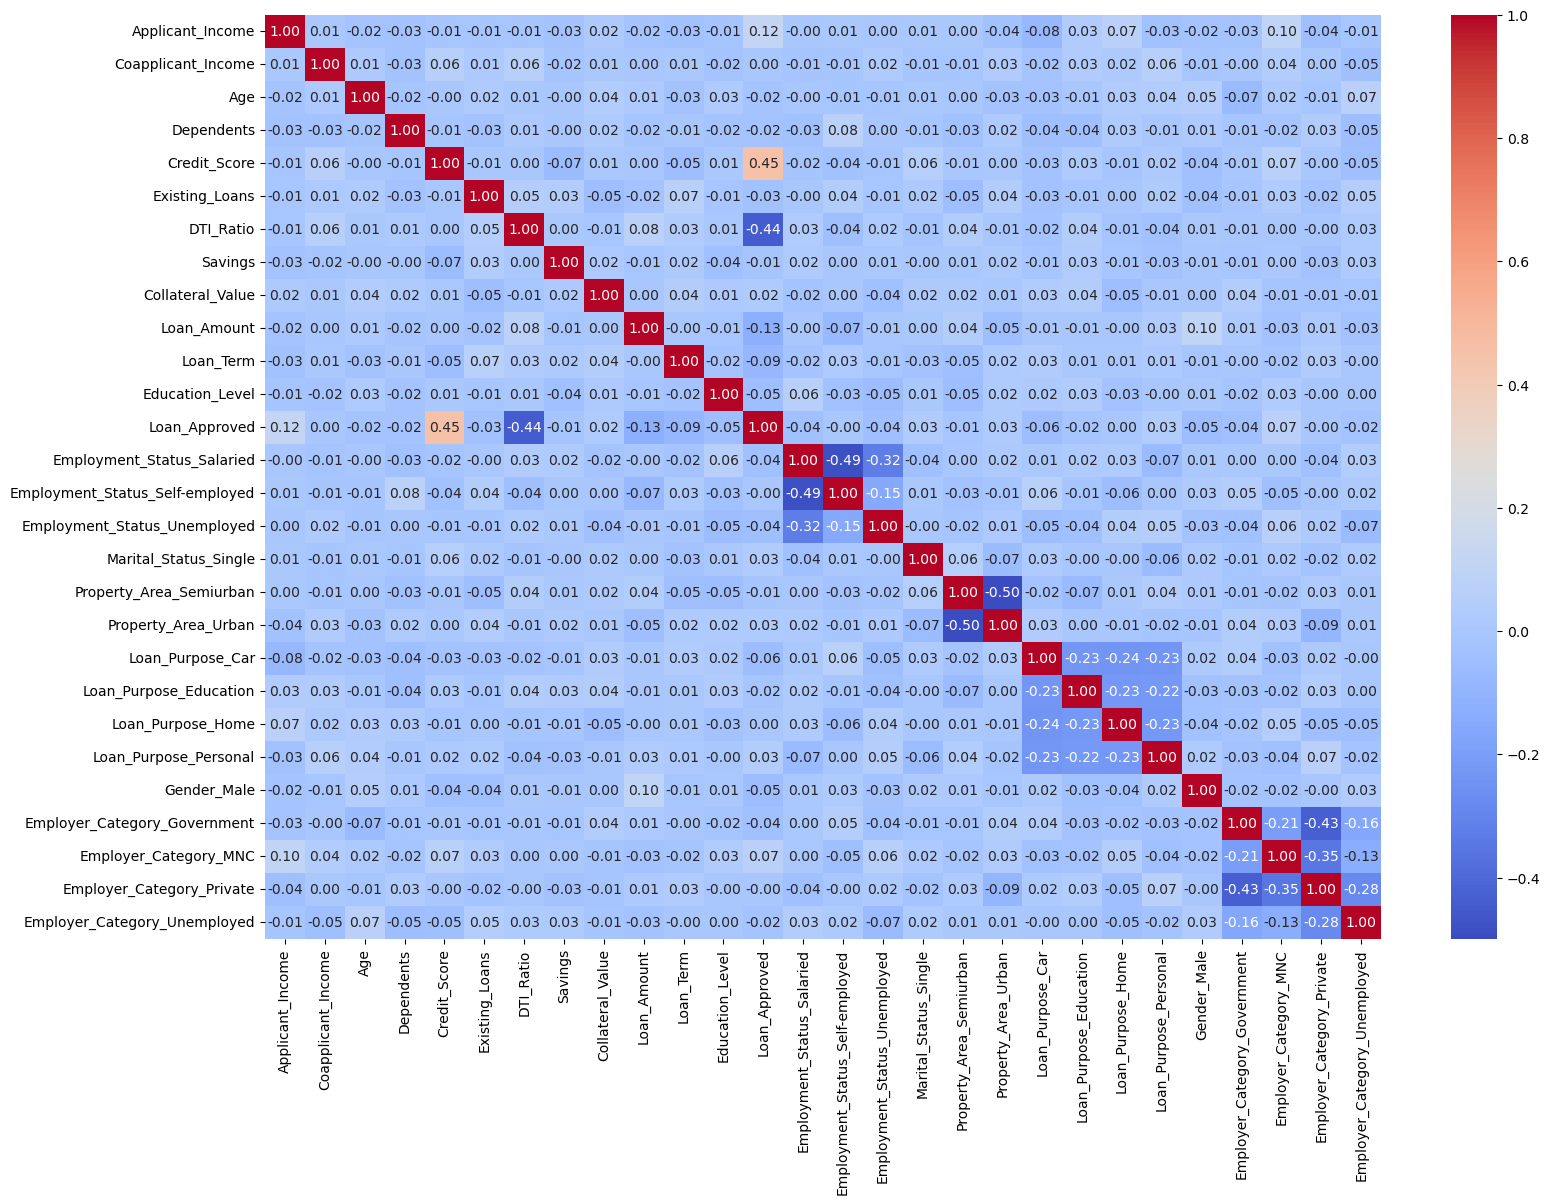

In [30]:

plt.figure(figsize = (18,12))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)

# TTS + Feature Scaling

In [31]:
X = df.drop("Loan_Approved" , axis=1)
Y = df["Loan_Approved"]

In [32]:
X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Urban,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

In [35]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Urban,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train and Evaluate Models

In [37]:
#Logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled , Y_train)

Y_pred = log_model.predict(X_test_scaled)

#Evaluate
print("Logistic Regression Model")
print("Precision: ", precision_score(Y_test,Y_pred))
print("Recall: ", recall_score(Y_test,Y_pred))
print("F1: ", f1_score(Y_test,Y_pred))
print("Accuracy: ", accuracy_score(Y_test,Y_pred))
print("Confusion Matrix: ", confusion_matrix(Y_test,Y_pred))

Logistic Regression Model
Precision:  0.7833333333333333
Recall:  0.7704918032786885
F1:  0.7768595041322314
Accuracy:  0.865
Confusion Matrix:  [[126  13]
 [ 14  47]]


In [38]:
#KNN

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(X_train_scaled , Y_train)

Y_pred = knn_model.predict(X_test_scaled)

#Evaluate
print("KNN Model")
print("Precision: ", precision_score(Y_test,Y_pred))
print("Recall: ", recall_score(Y_test,Y_pred))
print("F1: ", f1_score(Y_test,Y_pred))
print("Accuracy: ", accuracy_score(Y_test,Y_pred))
print("Confusion Matrix: ", confusion_matrix(Y_test,Y_pred))

KNN Model
Precision:  0.6274509803921569
Recall:  0.5245901639344263
F1:  0.5714285714285714
Accuracy:  0.76
Confusion Matrix:  [[120  19]
 [ 29  32]]


In [39]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled , Y_train)

Y_pred = nb_model.predict(X_test_scaled)

#Evaluate
print("Naive Bayes Model")
print("Precision: ", precision_score(Y_test,Y_pred))
print("Recall: ", recall_score(Y_test,Y_pred))
print("F1: ", f1_score(Y_test,Y_pred))
print("Accuracy: ", accuracy_score(Y_test,Y_pred))
print("Confusion Matrix: ", confusion_matrix(Y_test,Y_pred))

Naive Bayes Model
Precision:  0.8035714285714286
Recall:  0.7377049180327869
F1:  0.7692307692307693
Accuracy:  0.865
Confusion Matrix:  [[128  11]
 [ 16  45]]


# Feature Engineering

In [40]:
df["DTI_Ratio_sq"] = df["DTI_Ratio"] **2 
df["Credit_Score_sq"] = df["Credit_Score"] **2 

# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])


X = df.drop(columns = ["Loan_Approved", "DTI_Ratio", "Credit_Score"])
Y = df["Loan_Approved"]

In [41]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
#Logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled , Y_train)

Y_pred = log_model.predict(X_test_scaled)

#Evaluate
print("Logistic Regression Model")
print("Precision: ", precision_score(Y_test,Y_pred))
print("Recall: ", recall_score(Y_test,Y_pred))
print("F1: ", f1_score(Y_test,Y_pred))
print("Accuracy: ", accuracy_score(Y_test,Y_pred))
print("Confusion Matrix: ", confusion_matrix(Y_test,Y_pred))

Logistic Regression Model
Precision:  0.7903225806451613
Recall:  0.8032786885245902
F1:  0.7967479674796748
Accuracy:  0.875
Confusion Matrix:  [[126  13]
 [ 12  49]]


In [43]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(X_train_scaled , Y_train)

Y_pred = knn_model.predict(X_test_scaled)

#Evaluate
print("KNN Model")
print("Precision: ", precision_score(Y_test,Y_pred))
print("Recall: ", recall_score(Y_test,Y_pred))
print("F1: ", f1_score(Y_test,Y_pred))
print("Accuracy: ", accuracy_score(Y_test,Y_pred))
print("Confusion Matrix: ", confusion_matrix(Y_test,Y_pred))

KNN Model
Precision:  0.62
Recall:  0.5081967213114754
F1:  0.5585585585585585
Accuracy:  0.755
Confusion Matrix:  [[120  19]
 [ 30  31]]


In [44]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled , Y_train)

Y_pred = nb_model.predict(X_test_scaled)

#Evaluate
print("Naive Bayes Model")
print("Precision: ", precision_score(Y_test,Y_pred))
print("Recall: ", recall_score(Y_test,Y_pred))
print("F1: ", f1_score(Y_test,Y_pred))
print("Accuracy: ", accuracy_score(Y_test,Y_pred))
print("Confusion Matrix: ", confusion_matrix(Y_test,Y_pred))

Naive Bayes Model
Precision:  0.7833333333333333
Recall:  0.7704918032786885
F1:  0.7768595041322314
Accuracy:  0.865
Confusion Matrix:  [[126  13]
 [ 14  47]]
